# HW2 — UCB

**Course:** ID6002W Online and Reinforcement Learning (IIT Madras WSAI web-enabled M.Tech)

**Deadline:** Wednesday, 17 June 2026, 11:59 PM.

**Marks:** 6 (Parts A–D, 2 + 2 + 1 + 1 mark). Part E is not graded.


## About this homework

HW2 has two parts, in separate notebooks. **This notebook covers UCB (deterministic optimism) from Lecture 4.** The companion notebook covers Thompson Sampling (randomized optimism) from Lectures 5 and 6, and assumes you have completed this notebook first.

The task is broken into several short parts. The pattern in every part is the same:

1. **Implement** the algorithm's core logic in a `# TODO` cell (you do this once).
2. **Run** the pre-filled experiment and plotting cells.
3. **Comment** on what you see in a short write-up cell.

Your code is needed to produce the plots, but **marks are awarded for the written observations** — your interpretation of what the plots show and why. The marks for each part are stated in that part's heading. The plotting and experiment scaffolding is provided; your focus is on getting the algorithm right and reading the results carefully.

**Prerequisite:** the warmup and Task implementations from HW1. We reuse the same `BernoulliBandit`, `run_experiment`, and plotting helpers here.


## Provided codebase (from HW1)

The next four cells provide imports, `BernoulliBandit`, plotting helpers, and `run_experiment`. These are identical to HW1 — included here so this homework is self-contained. Run them once, then move on to Task 1.

A further environment, `GaussianBandit`, is introduced later in Parts D and E, right before the experiments that use it.


In [3]:
# === Setup: imports and plotting style ===

import numpy as np                  # numerical arrays + random number generators
import matplotlib.pyplot as plt     # plotting
from functools import partial       # used later to "bind" hyperparameters (e.g. ε) into algorithms

%matplotlib inline

# A few plot defaults so figures look consistent across the notebook.
plt.rcParams["figure.dpi"] = 100    # higher dpi = sharper figures
plt.rcParams["axes.grid"] = True    # show grid by default
plt.rcParams["grid.alpha"] = 0.3    # faded grid lines so they don't dominate

# Fixed starting seed for reproducibility (see warmup for explanation).
BASE_SEED = 20260516

In [4]:
# === Provided: BernoulliBandit environment ===

class BernoulliBandit:
    """
    K-arm Bernoulli bandit.

    Parameters
    ----------
    means : sequence of floats in [0, 1]
        True mean reward of each arm.
    rng : np.random.Generator
        Source of randomness owned by this environment instance.

    Attributes
    ----------
    K : int                       Number of arms.
    means : np.ndarray (K,)       True means.
    best_mean : float             max of `means` (used for regret).
    best_arm : int                argmax of `means`.
    pull_counts : np.ndarray (K,) Number of times each arm has been pulled.
    """

    def __init__(self, means, rng):
        # Store true means as a numpy array of floats.
        self.means = np.asarray(means, dtype=float)

        # Sanity check: Bernoulli means must be valid probabilities.
        if np.any((self.means < 0) | (self.means > 1)):
            raise ValueError("Bernoulli means must lie in [0, 1].")

        self.K = len(self.means)               # number of arms
        self.rng = rng                          # this env's own random generator

        # Pre-compute best arm and its mean — used to compute regret.
        self.best_mean = float(self.means.max())
        self.best_arm = int(np.argmax(self.means))

        # Bookkeeping: how often each arm has been pulled so far.
        # (Algorithms may also track this internally; this is for sanity-checking.)
        self.pull_counts = np.zeros(self.K, dtype=int)

    def pull(self, arm):
        """Pull arm `arm`. Returns a 0/1 reward sampled Bernoulli(means[arm])."""
        self.pull_counts[arm] += 1
        # rng.random() draws uniform in [0, 1); reward = 1 with probability means[arm].
        return int(self.rng.random() < self.means[arm])

    def instantaneous_regret(self, arm):
        """Expected regret incurred by pulling arm `arm`: best_mean − means[arm].

        Note this is the *expected* regret, not the realised one. We use expected
        regret throughout because it's smoother and the standard quantity to plot.
        """
        return self.best_mean - self.means[arm]

In [5]:
# === Provided: plotting helpers ===

def plot_cumulative_regret(regrets, label, ax):
    """Plot cumulative regret for a single run.

    Parameters
    ----------
    regrets : (T,) instantaneous regret per round (not cumulative — we sum here).
    """
    ax.plot(np.cumsum(regrets), label=label)   # cumsum turns per-round regret into cumulative
    ax.set_xlabel("Round t")
    ax.set_ylabel("Cumulative regret")
    ax.legend()


def plot_averaged_regret(regret_matrix, label, ax, with_band=True):
    """Plot mean cumulative regret across seeds, with optional ±1 std band.

    Parameters
    ----------
    regret_matrix : (n_seeds, T) instantaneous regret per round per seed.
    """
    # Each row is one run; cumsum along time gives (n_seeds, T) cumulative regrets.
    cum = np.cumsum(regret_matrix, axis=1)

    # Aggregate across seeds: mean curve plus standard-deviation band.
    mean = cum.mean(axis=0)
    std = cum.std(axis=0)

    t = np.arange(1, cum.shape[1] + 1)
    line, = ax.plot(t, mean, label=label)
    if with_band:
        # Shaded band shows variability across seeds — wider band = noisier algorithm.
        ax.fill_between(t, mean - std, mean + std, alpha=0.2, color=line.get_color())
    ax.set_xlabel("Round t")
    ax.set_ylabel("Cumulative regret  (mean ± 1 std)")
    ax.legend()


def plot_arm_pulls(arm_sequence, ax, K=None):
    """Strip plot: which arm was pulled at which round.

    Useful for visualising the exploration pattern of an algorithm.

    Parameters
    ----------
    arm_sequence : (T,) integer arm indices.
    """
    arm_sequence = np.asarray(arm_sequence)
    t = np.arange(len(arm_sequence))
    ax.scatter(t, arm_sequence, s=6, alpha=0.5)   # small, semi-transparent dots
    ax.set_xlabel("Round t")
    ax.set_ylabel("Arm pulled")
    if K is None:
        K = int(arm_sequence.max()) + 1
    ax.set_yticks(np.arange(K))   # one tick per arm

In [6]:
# === Provided: run_experiment helper ===

def run_experiment(algo_fn, env_factory, T, n_seeds, base_seed=BASE_SEED):
    """Run `algo_fn` for `n_seeds` independent seeds.

    Parameters
    ----------
    algo_fn : callable
        Signature `algo_fn(env, T) -> (arm_sequence, regret_sequence)`.
        Bind any extra params (e.g. ε for ε-greedy) with `functools.partial`
        before passing.
    env_factory : callable
        Signature `env_factory(rng) -> BernoulliBandit`. Builds a fresh env per
        seed — so each seed sees an independent stream of rewards.
    T : int                Horizon.
    n_seeds : int          Number of independent runs to average over.
    base_seed : int        Seeds used are base_seed + 0, base_seed + 1, ...

    Returns
    -------
    regret_matrix : (n_seeds, T) float array of instantaneous regrets.
    arm_matrix    : (n_seeds, T) int   array of arms pulled.
    """
    # Pre-allocate output matrices: one row per seed, one column per round.
    regret_matrix = np.zeros((n_seeds, T))
    arm_matrix = np.zeros((n_seeds, T), dtype=int)

    for s in range(n_seeds):
        # Each run gets its own RNG, derived from base_seed + s.
        # This makes the whole experiment reproducible while keeping runs independent.
        rng = np.random.default_rng(base_seed + s)
        env = env_factory(rng)

        # Run the algorithm. It returns the arms it pulled and the per-round regret.
        arms, regrets = algo_fn(env, T)

        regret_matrix[s] = regrets
        arm_matrix[s] = arms

    return regret_matrix, arm_matrix

---

## Task 1 — Upper Confidence Bound (6 marks)

Recall the UCB algorithm from Lecture 4. In simple words: maintain a confidence interval around each arm's mean, and pull the arm whose upper end of the confidence interval is the largest. The confidence interval comes from Hoeffding's inequality. An arm is pulled either because it looks good (its empirical mean is high), or because we are still unsure about it (its confidence interval is wide). UCB therefore handles exploration and exploitation automatically, with no $\varepsilon$ to tune.

Following the notation from Lecture 4, the **UCB index** of arm $i$ at round $t$ is

$$ UCB_i(t) \;=\; \hat\mu_i(t) \;+\; \sqrt{\dfrac{c\,\log T}{T_i(t)}}, $$

where $\hat\mu_i(t)$ is the empirical mean of the rewards seen from arm $i$ so far, $T_i(t)$ is the number of times arm $i$ has been pulled, and $c$ is a constant. We refer to $UCB_i(t)$ as the **index** of arm $i$. The algorithm pulls each arm once to start, and then at every round pulls $A_t = \arg\max_i UCB_i(t-1)$, i.e., the arm with the largest index.

You will implement this algorithm once, and then use it to study UCB in five short parts. Each part presents one or two plots followed by a question. The marks are:

* **A** — regret curves and how the UCB index evolves *(2 marks)*
* **B** — tuning the width of the confidence interval, the constant $c$ *(2 marks)*
* **C** — the anytime version of UCB: $\log t$ instead of $\log T$ *(1 mark)*
* **D** — UCB when rewards are real-valued: Gaussian bandits *(1 mark)*
* **E** — what happens when the variance of the Gaussian bandit is unknown *(not graded; attempt if you wish)*

All parts call the same `ucb` function with different arguments.

In [ ]:
# === Task 1: UCB implementation ===

def ucb(env, T, c=2.0, mode="fixed_horizon", sigma=1.0, T_assumed=None, return_trace=False):
    """UCB on a bandit environment (Bernoulli, or — in Parts D, E — Gaussian).

    The index for arm i, exactly as in Lecture 4, is

        UCB_i = mu_hat_i + sigma * sqrt( c * log(time_factor) / T_i )

    where time_factor depends on the mode:
        mode = "fixed_horizon"  ->  time_factor = T_assumed   (a constant; the Lecture 4 default, log T)
        mode = "anytime"        ->  time_factor = t           (the current round; Part C, log t)

    For Bernoulli arms use sigma = 1, which recovers the lecture's sqrt(c log T / T_i).
    (sigma only starts to matter in Parts D and E, with Gaussian rewards.)

    Initialise by pulling each arm once; then pull arg max_i UCB_i each round.

    Bookkeeping to maintain per arm: the running sum of rewards and the number of pulls.
    (For a Bernoulli arm these are equivalently the number of successes and the total
    number of pulls; either way the empirical mean is sum_rewards / counts.)

    Parameters
    ----------
    env          : bandit with .K, .pull(arm), .instantaneous_regret(arm), .rng
    T            : int     horizon (number of rounds to play)
    c            : float   constant inside the bonus (the tuning knob in Part B)
    mode         : "fixed_horizon" (default) or "anytime" (Part C)
    sigma        : float   noise scale (1.0 for Bernoulli; varied in Parts D, E)
    T_assumed    : int     horizon used by "fixed_horizon" mode; defaults to T
    return_trace : bool    if True, also return per-round bookkeeping (used by the Part A plot)

    Returns
    -------
    arm_sequence    : (T,) int     arm pulled at each round
    regret_sequence : (T,) float   instantaneous (expected) regret per round
    trace           : dict         returned ONLY if return_trace=True. Provided for plotting,
                                    you do not need to touch it. Keys "means_hat" and "counts",
                                    each a (T, K) array of the running mean / pull count per arm.
    """
    K = env.K
    if T_assumed is None:
        T_assumed = T

    arm_sequence = np.zeros(T, dtype=int)
    regret_sequence = np.zeros(T)

    # Per-arm bookkeeping.
    sum_rewards = np.zeros(K)
    counts = np.zeros(K, dtype=int)

    # Provided: storage for the Part A plot. Filled at the bottom of the loop; do not edit.
    means_hist = np.zeros((T, K))
    counts_hist = np.zeros((T, K))

    for t_idx in range(T):
        t = t_idx + 1                                          # 1-indexed round
        time_factor = T_assumed if mode == "fixed_horizon" else t

        # TODO: choose the arm `a` to pull this round.
        #   - the empirical mean of arm i is sum_rewards[i] / counts[i]
        #   - any arm with counts[i] == 0 must be pulled before any already-pulled arm
        #     (treat its index as +inf). Over the first K rounds this pulls each arm once.
        #   - otherwise  index_i = mean_i + sigma * sqrt(c * log(time_factor) / counts[i])
        #   - pull the arg max of index_i; break ties uniformly at random using env.rng
        unpulled_arms = np.where(counts == 0)[0]
        if len(unpulled_arms) > 0:
            a = env.rng.choice(unpulled_arms)
        else:
            means = sum_rewards / counts
            upper_confidence = means + sigma * np.sqrt(c * np.log(time_factor) / counts)
            
            # Find all arms matching the max UCB index to break ties randomly
            max_val = np.max(upper_confidence)
            best_arms = np.where(upper_confidence == max_val)[0]
            a = env.rng.choice(best_arms)

        # Pull, observe reward, update bookkeeping. (Provided.)
        r = env.pull(a)
        sum_rewards[a] += r
        counts[a] += 1

        arm_sequence[t_idx] = a
        regret_sequence[t_idx] = env.instantaneous_regret(a)

        # Provided: record bookkeeping for the Part A plot. Do not edit.
        means_hist[t_idx] = np.where(counts > 0, sum_rewards / np.maximum(counts, 1), 0.0)
        counts_hist[t_idx] = counts

    if return_trace:
        return arm_sequence, regret_sequence, {"means_hat": means_hist, "counts": counts_hist}
    return arm_sequence, regret_sequence


### Part A — regret curves and how the UCB index evolves *(2 marks)*

We use fixed-horizon UCB with $c = 2$ on two 2-arm Bernoulli bandit instances:

* an **easy** instance, means $[0.7, 0.3]$, gap $\Delta = 0.4$, and
* a **hard** instance, means $[0.55, 0.45]$, gap $\Delta = 0.1$.

The first plot compares the cumulative regret on the two instances. The second plot takes a single seed on each instance and shows UCB at work: for each arm, the empirical mean $\hat\mu_i(t)$, the confidence interval $[\hat\mu_i \pm U_i]$ with $U_i = \sqrt{c\log T / T_i}$, and the index $UCB_i(t) = \hat\mu_i + U_i$.

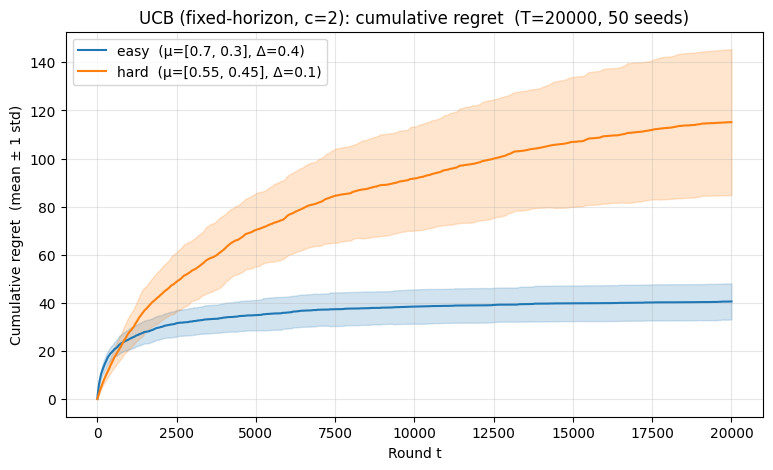

instance          avg pulls arm 0 (best)   avg pulls arm 1 (worse)
easy (Δ=0.4)                       19898                       102
hard (Δ=0.1)                       18849                      1151


In [13]:
# === Task 1, Part A: regret on an easy vs a hard instance ===

T = 20000
n_seeds = 50

def env_factory_easy(rng):
    """2-arm Bernoulli, gap Δ = 0.4."""
    return BernoulliBandit([0.7, 0.3], rng)

def env_factory_hard(rng):
    """2-arm Bernoulli, gap Δ = 0.1."""
    return BernoulliBandit([0.55, 0.45], rng)

# ucb is called with default arguments: fixed-horizon, c=2, sigma=1.
easy_regret, easy_arms = run_experiment(ucb, env_factory_easy, T, n_seeds)
hard_regret, hard_arms = run_experiment(ucb, env_factory_hard, T, n_seeds)

fig, ax = plt.subplots(figsize=(9, 5))
plot_averaged_regret(easy_regret, "easy  (μ=[0.7, 0.3], Δ=0.4)", ax)
plot_averaged_regret(hard_regret, "hard  (μ=[0.55, 0.45], Δ=0.1)", ax)
ax.set_title(f"UCB (fixed-horizon, c=2): cumulative regret  (T={T}, {n_seeds} seeds)")
plt.show()

# Average pull counts per arm (arm 0 is the best arm in both instances).
# run_experiment returns the per-round arm choices; count how many times each arm was pulled.
easy_pull_counts = np.array([(easy_arms == k).sum(axis=1) for k in range(2)]).mean(axis=1)
hard_pull_counts = np.array([(hard_arms == k).sum(axis=1) for k in range(2)]).mean(axis=1)
print(f"{'instance':<16}{'avg pulls arm 0 (best)':>24}{'avg pulls arm 1 (worse)':>26}")
print(f"{'easy (Δ=0.4)':<16}{easy_pull_counts[0]:>24.0f}{easy_pull_counts[1]:>26.0f}")
print(f"{'hard (Δ=0.1)':<16}{hard_pull_counts[0]:>24.0f}{hard_pull_counts[1]:>26.0f}")


**Write-up (TODO) — 1 mark.**

The easy curve flattens to a low value, while the hard curve keeps climbing through $T = 20000$. Lecture 4 showed that for UCB, $T_i(T) \le 8 \log T / \Delta_i^2 + 1$, where $\Delta_i = \mu^\star - \mu_i$ is the gap. The piece of this bound that matters here is the $1/\Delta^2$ scaling. Use it to explain the late-time behaviour of the two curves, and check it against the printed pull counts. Also explain one early-time observation: why is the easy instance's cumulative regret *higher* than the hard one during the first few rounds?

*(TODO: write your observations below.)*


**Observations**:
* *Late-time behaviour*: Maximum number of arm pulls of worse arm scales with $1 / \ \Delta_i^2$ which would cause number of arm pulls and cumulative regret to grow much faster in hard case. So theoritically we expect ratio of arm pulls between hard and easy to be at most $(1/0.1^2) / (1/0.4^2) = 16$. Actual ratio (hard / easy) of arm 1 (worse arm) is $1095 / 106 = 10.33$ - this is less than the upper bound given by theoritical ratio so it aligns with theory.
* *Early behaviour*: At the start, each arm must be pulled at least once. And in subsequent early rounds, frequency of worse arm (arm 1) pulls in both easy and hard is about the same, since there's insufficient data to learn good means. But instantaneous regret at a round is $\Delta$ (0.4 for easy, 0.1 for hard), which means easy experiences 4 times more regret than hard on pulling arm 1, so its cumulative regret is higher. Later once we have sufficient data, easy pulls arm 1 much less and hence its cumulative regret becomes much less than hard.

**Seeing UCB at work.** One seed per instance, shorter horizon so that the early dynamics are visible. For each arm we plot the index $UCB_i(t)$ (solid — this is what the algorithm uses to pick an arm), the confidence interval (shaded), the empirical mean (dashed), and the true mean (dotted). The two panels show the easy and hard instances side by side.

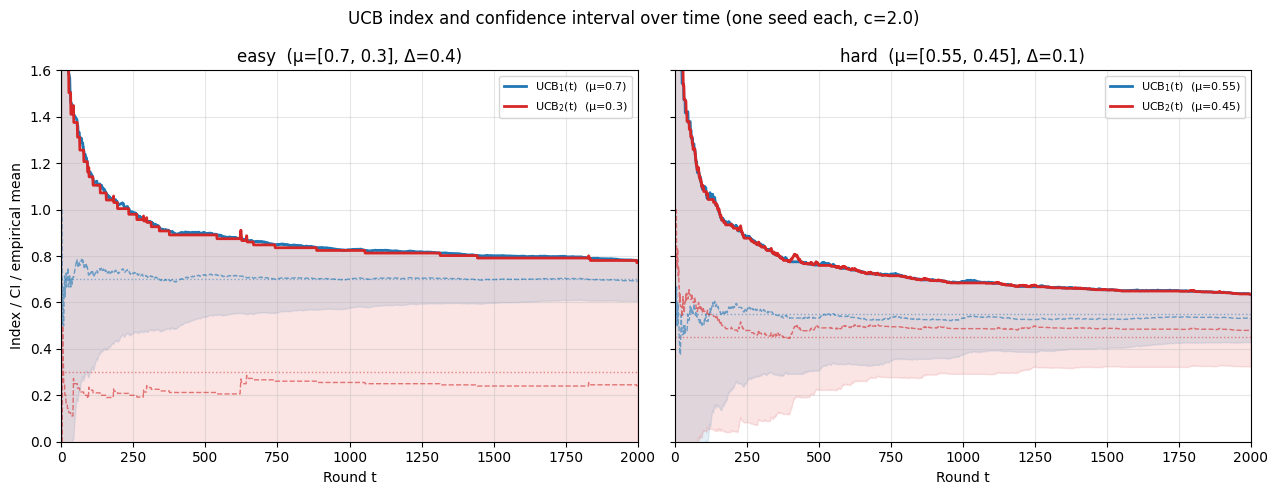

In [14]:
# === Task 1, Part A: seeing UCB at work — easy vs hard, side by side ===

T_band = 2000
c = 2.0

def ucb_deepdive_panel(ax, env_factory, title):
    rng = np.random.default_rng(BASE_SEED)
    env = env_factory(rng)
    _, _, trace = ucb(env, T_band, c=c, return_trace=True)

    means_hat = trace["means_hat"]
    counts = trace["counts"]
    t_axis = np.arange(1, T_band + 1)

    # Fixed-horizon bonus: U_i(t) = sqrt(c * log(T_band) / N_i(t)).
    with np.errstate(divide="ignore", invalid="ignore"):
        U = np.sqrt(c * np.log(T_band) / counts)
    valid = counts > 0
    mu = np.where(valid, means_hat, np.nan)
    upper = np.where(valid, means_hat + U, np.nan)
    lower = np.where(valid, means_hat - U, np.nan)

    colors = ["#1f77b4", "#d62728"]
    for i in range(env.K):
        ax.fill_between(t_axis, lower[:, i], upper[:, i], color=colors[i], alpha=0.12)
        ax.plot(t_axis, upper[:, i], color=colors[i], lw=2.0,
                label=f"UCB$_{i+1}$(t)  (μ={env.means[i]})")
        ax.plot(t_axis, mu[:, i], color=colors[i], lw=1.0, alpha=0.6, ls="--")
        ax.axhline(env.means[i], color=colors[i], ls=":", lw=1, alpha=0.5)
    ax.set_ylim(0.0, 1.6); ax.set_xlim(0, T_band)
    ax.set_xlabel("Round t"); ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ucb_deepdive_panel(axes[0], env_factory_easy, "easy  (μ=[0.7, 0.3], Δ=0.4)")
ucb_deepdive_panel(axes[1], env_factory_hard, "hard  (μ=[0.55, 0.45], Δ=0.1)")
axes[0].set_ylabel("Index / CI / empirical mean")
fig.suptitle(f"UCB index and confidence interval over time (one seed each, c={c})")
plt.tight_layout()
fig.subplots_adjust(left=0.06)
plt.show()


**Write-up (TODO) — 1 mark.**

In both panels, the two solid index curves stay close together near the top and keep swapping the lead — even on the easy instance, where the worse arm is pulled only a few times. When you pull an arm, its bonus shrinks for certain, while its empirical mean only fluctuates up or down. Use this to explain why being on top is *self-correcting* (your explanation should account for the occasional upward jumps in the solid curves). Then, in terms of pull counts, explain why the worse arm keeps getting pulled almost forever in the hard case but only rarely in the easy case.

*(TODO: write your observations below.)*


**Observations**:

When an arm is pulled, its uncertainity and UCB reduce below UCB of the other arm, so next round the other arm gets pulled due to higher UCB. So the top arm (UCB) keeps getting swapped. Occassionally `BernoulliBandit` randomly gives a high reward for the worse arm, which causes temporary upward jump (that arm gets favoured for a few rounds). This explains why an arm's UCB being on top is *self-correcting* (reducing).

After round 600, in the easy case red mean dashed line (worse arm mean) is mostly steady, indicating very few arm pulls. Whereas in hard case the worse arm's mean keeps fluctuating, indicating more arm pulls of the worse arm. It's due to low gap $\Delta = 0.1$ in hard case, which makes it uncertain & more difficult for UCB to seperate the 2 arms.

### Part B — tuning the confidence width *(2 marks)*

The constant $c$ controls how wide the confidence interval is, and therefore how strongly the bonus $\sqrt{c\log T / T_i}$ inflates each arm's index. It is a hyper-parameter of the UCB algorithm. If $c$ is too small, the algorithm explores very little. If $c$ is too large, it explores too much.

In this part you sweep $c$ over a wide range on the **hard** 3-arm instance $\mu = (0.55, 0.50, 0.45)$, the same instance used in Lecture 4. The four values are $c \in \{0.05, 0.25, 2, 20\}$, with the labels from Lecture 4: $c = 0.05$ too small, $c = 0.25$ just right, $c = 2$ the textbook (theoretically safe) value, and $c = 20$ too large.

**Plot 1.** Cumulative regret, averaged over many seeds, for each value of $c$.

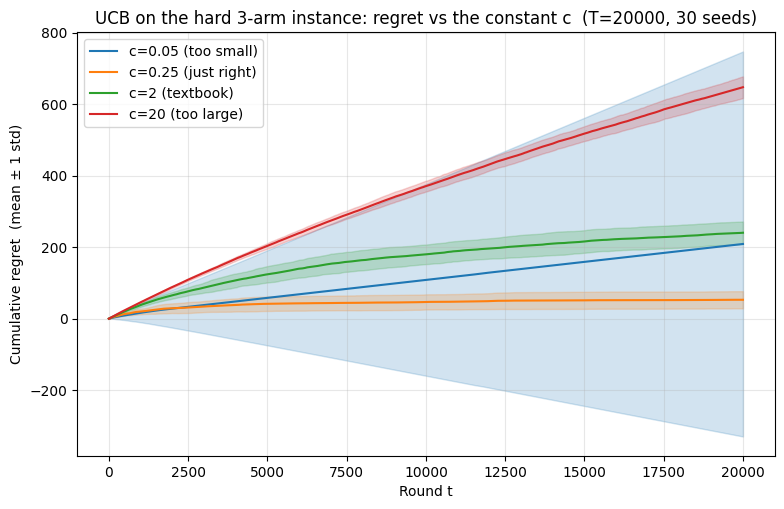

In [16]:
# === Task 1, Part B: cumulative regret across a sweep of c ===

T = 20000
n_seeds = 30  # 100   # reduce (e.g. to 30) if this is slow on your machine

def env_factory_hard3(rng):
    """3-arm Bernoulli hard instance from Lecture 4."""
    return BernoulliBandit([0.55, 0.50, 0.45], rng)

c_values = [0.05, 0.25, 2.0, 20.0]
c_labels = {0.05: "c=0.05 (too small)", 0.25: "c=0.25 (just right)",
            2.0:  "c=2 (textbook)",     20.0: "c=20 (too large)"}

# Per-seed cumulative regret for each c; reused by Plot 2.
cumreg_by_c = {}

fig, ax = plt.subplots(figsize=(9, 5.5))
for c in c_values:
    algo = partial(ucb, c=c)
    inst_regret, _ = run_experiment(algo, env_factory_hard3, T, n_seeds)
    cumreg_by_c[c] = inst_regret.cumsum(axis=1)               # (n_seeds, T)
    plot_averaged_regret(inst_regret, c_labels[c], ax)
ax.set_title(f"UCB on the hard 3-arm instance: regret vs the constant c  (T={T}, {n_seeds} seeds)")
plt.show()


**Write-up (TODO) — 1 mark.**

Describe what goes wrong at each extreme: very small $c$ and very large $c$. Why is the theoretically "safe" textbook value $c = 2$ beaten here by the smaller $c = 0.25$? (Connect to Lecture 4: the Hoeffding-based confidence interval is an *upper bound* on the deviation, so the constant it suggests is conservative.)

*(TODO: write your observations below.)*

**Observations**:
* At very large $c = 20$, the bonus $\sqrt{c \ln{T} / T_i}$ is dominated by $c$ so that Upper Confidence Bound is large for all arms and the arms chosen each turn are basically random, leading to higher rate of growth in cumulative regret. 
* At small $c$, the exploration bonus is too small leading to almost pure exploitation -- in many runs, UCB gets unlucky early on and "locks in" to a suboptimal arm. 
* The theoretical value $c = 2$ derived from the Hoeffding-based confidence interval is an *upper bound* on the deviation, so the constant it suggests is conservative, and in this case beaten by experimentally ideal $c = 0.25$ .


**Plot 2 — what the average curve hides.** A mean regret curve hides how different seeds behave. We now look at the *final cumulative regret* of each individual seed, one strip per value of $c$. Pay particular attention to the smallest value of $c$, and compare where most of its points sit against where its mean (red marker) sits.

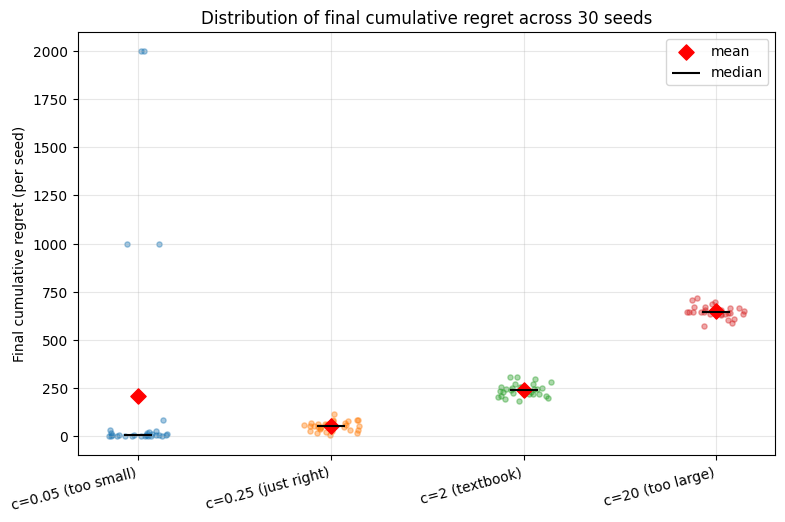

In [17]:
# === Task 1, Part B: distribution of final cumulative regret across seeds ===

fig, ax = plt.subplots(figsize=(9, 5.5))
positions = np.arange(len(c_values))
for j, c in enumerate(c_values):
    pts = cumreg_by_c[c][:, -1]                # final cumulative regret per seed
    jitter = (np.random.default_rng(j).random(len(pts)) - 0.5) * 0.3
    ax.scatter(np.full_like(pts, positions[j], dtype=float) + jitter, pts, s=14, alpha=0.4)
    ax.scatter([positions[j]], [pts.mean()], color="red", marker="D", s=60, zorder=5,
               label="mean" if j == 0 else None)
    ax.scatter([positions[j]], [np.median(pts)], color="black", marker="_", s=400, zorder=5,
               label="median" if j == 0 else None)
ax.set_xticks(positions)
ax.set_xticklabels([c_labels[c] for c in c_values], rotation=15, ha="right")
ax.set_ylabel("Final cumulative regret (per seed)")
ax.set_title(f"Distribution of final cumulative regret across {n_seeds} seeds")
ax.legend()
plt.show()


**Plot 3 — looking inside a failure run.** To see what goes wrong in a high-regret run, we plot the UCB indices of all three arms on a single seed, for two values of $c$: $c = 0.25$ (just right) and $c = 0.05$ (too small). Compare the three index curves across the two panels.

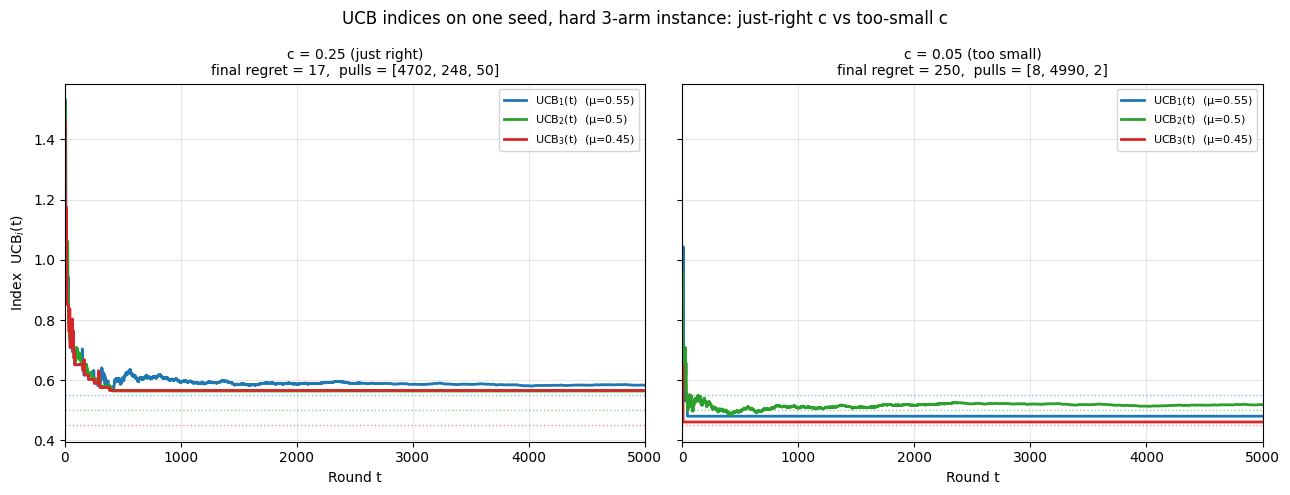

In [18]:
# === Task 1, Part B: what under-exploration looks like (one seed) ===

T_band = 5000
seed = BASE_SEED + 7                           # a seed where c=0.05 commits to a wrong arm

def ucb_index_panel(ax, c, title):
    rng = np.random.default_rng(seed)
    env = env_factory_hard3(rng)
    arms_run, regrets_run, trace = ucb(env, T_band, c=c, return_trace=True)
    means_hat = trace["means_hat"]; counts = trace["counts"]
    t_axis = np.arange(1, T_band + 1)
    with np.errstate(divide="ignore", invalid="ignore"):
        U = np.sqrt(c * np.log(T_band) / counts)
    valid = counts > 0
    upper = np.where(valid, means_hat + U, np.nan)
    colors = ["#1f77b4", "#2ca02c", "#d62728"]
    for i in range(env.K):
        ax.plot(t_axis, upper[:, i], color=colors[i], lw=2.0,
                label=f"UCB$_{i+1}$(t)  (μ={env.means[i]})")
        ax.axhline(env.means[i], color=colors[i], ls=":", lw=1, alpha=0.5)
    ax.set_xlim(0, T_band); ax.set_xlabel("Round t")

    # Append final cumulative regret and per-arm pulls to the title.
    final_reg = regrets_run.sum()
    pulls = [int((arms_run == i).sum()) for i in range(env.K)]
    detail = f"final regret = {final_reg:.0f},  pulls = {pulls}"
    ax.set_title(f"{title}\n{detail}", fontsize=10)
    ax.legend(loc="upper right", fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ucb_index_panel(axes[0], 0.25, "c = 0.25 (just right)")
ucb_index_panel(axes[1], 0.05, "c = 0.05 (too small)")
axes[0].set_ylabel("Index  UCB$_i$(t)")
fig.suptitle(f"UCB indices on one seed, hard 3-arm instance: just-right c vs too-small c")
plt.tight_layout()
plt.show()


**Write-up (TODO) — 1 mark.**

For the smallest $c$, the mean (Plot 2) sits far above the median. What does this say about the shape of the regret distribution, and what kind of run produces the high-regret outliers? Plot 3 shows one such run beside a healthy one: explain why a small $c$ breaks the self-correcting behaviour you described in Part A. (Hint: what happens to a small bonus once an arm has been pulled a moderate number of times?)

*(TODO: write your observations below.)*

**Observations**: For small $c = 0.05$, the high-regret extreme outliers cause the regret distribution to become very right-skewed in shape. These outliers are produced by very unlucky runs (such as the one shown in Plot 3) where very early on suboptimal arm is chosen, but UCB is unable to correct since exploration bonus is very low and most of the time just exploitation is done of the chosen suboptimal arm.

### Part C — the anytime version of UCB *(1 mark)*

The fixed-horizon UCB index uses $\log T$ inside the bonus, which requires knowing the total number of rounds $T$ in advance. The **anytime** version replaces $\log T$ with $\log t$, where $t$ is the current round number. In the `ucb` function, this is `mode="anytime"`.

The plot below compares the two versions on the hard 3-arm instance from Part B. Both are run over the same actual horizon $T = 20000$ with $c = 2$; the fixed-horizon version is additionally told the correct value of $T$, while the anytime version does not use $T$ at all.

**Plot — anytime vs fixed-horizon.**

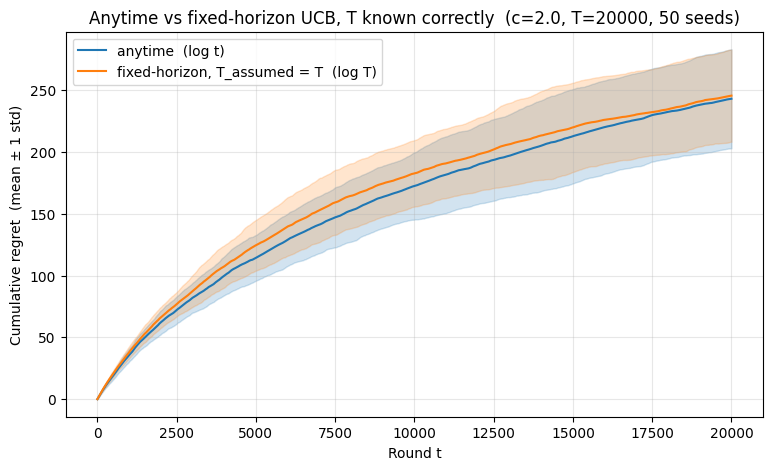

In [19]:
# === Task 1, Part C: anytime vs fixed-horizon, T known correctly ===

T = 20000
n_seeds = 50
c = 2.0

anytime_regret, _ = run_experiment(
    partial(ucb, c=c, mode="anytime"), env_factory_hard3, T, n_seeds)
fixed_regret, _ = run_experiment(
    partial(ucb, c=c, mode="fixed_horizon"), env_factory_hard3, T, n_seeds)

fig, ax = plt.subplots(figsize=(9, 5))
plot_averaged_regret(anytime_regret, "anytime  (log t)", ax)
plot_averaged_regret(fixed_regret, "fixed-horizon, T_assumed = T  (log T)", ax)
ax.set_title(f"Anytime vs fixed-horizon UCB, T known correctly  (c={c}, T={T}, {n_seeds} seeds)")
plt.show()


**Write-up (TODO) — 1 mark.**

The two curves are nearly identical — why? (Compare $\log t$ and $\log T$ over the range $K \le t \le T$, and remember that the bonus uses the *square root* of this term.) Next, notice that $c$ and $T_{\text{assumed}}$ enter the bonus only through the product $c \cdot \log T_{\text{assumed}}$, so changing one is equivalent to changing the other. In what sense is there only *one* hyper-parameter and not two, and what does the anytime version eliminate from this list (while leaving what still to tune)?

*(TODO: write your observations below.)*

**Observation**: $\sqrt{\ln{t}}$ grows very slowly and is almost constant over the whole range (till $T = 20000$), so result of using $t$ instead of $T$ is nearly identical. Also since only the product $c \ln{T_{assumed}}$ is used in exploration bonus, so it practically acts as a single hyperparameter (since changing one is equivalent to appropriately changing the other). The anytime version eliminates $T_{assumed}$ hyperparameter while still leaving $c$ to tune.

### Part D — UCB for Gaussian rewards *(1 mark)*

So far the rewards have been Bernoulli (0 or 1). We now consider **Gaussian rewards**. Each arm produces a noisy reward $X_t = \mu_i + \epsilon_t$, where $\epsilon_t \sim \mathcal{N}(0, \sigma^2)$. The noise standard deviation $\sigma$ is the same for all arms and is known to the algorithm.

The UCB index extends naturally:

$$ UCB_i(t) \;=\; \hat\mu_i(t) \;+\; \sigma \sqrt{\dfrac{c \, \log T}{T_i(t)}}. $$

The bonus now scales with $\sigma$: the confidence interval around an empirical mean is wider when the noise is larger. (For Bernoulli rewards the confidence width came from Hoeffding's inequality for bounded rewards; for Gaussian rewards it comes from the same sub-Gaussian idea, now with the known scale $\sigma$ in place of the bound.) The cell below defines a `GaussianBandit` environment, on the same lines as `BernoulliBandit`. You do not need to edit it.

In [20]:
# === Provided: GaussianBandit environment ===

class GaussianBandit:
    """K-arm bandit with Gaussian rewards.

    Each arm i has true mean means[i]. When arm i is pulled, the reward is
    drawn from N(means[i], sigma^2). The noise standard deviation sigma is
    the same for all arms.
    """
    def __init__(self, means, sigma, rng):
        self.means = np.asarray(means, dtype=float)
        self.sigma = float(sigma)
        self.K = len(self.means)
        self.rng = rng
        self.best_mean = float(self.means.max())
        self.best_arm = int(np.argmax(self.means))
        self.pull_counts = np.zeros(self.K, dtype=int)

    def pull(self, a):
        self.pull_counts[a] += 1
        return float(self.rng.normal(self.means[a], self.sigma))

    def instantaneous_regret(self, a):
        return self.best_mean - self.means[a]


**Plot — low vs high noise.** Same arm means as in Part B, $\mu = (0.55, 0.50, 0.45)$, compared at two noise levels: $\sigma = 0.3$ (low) and $\sigma = 1.0$ (high). In each case we tell the algorithm the correct $\sigma$ via the `sigma` argument.

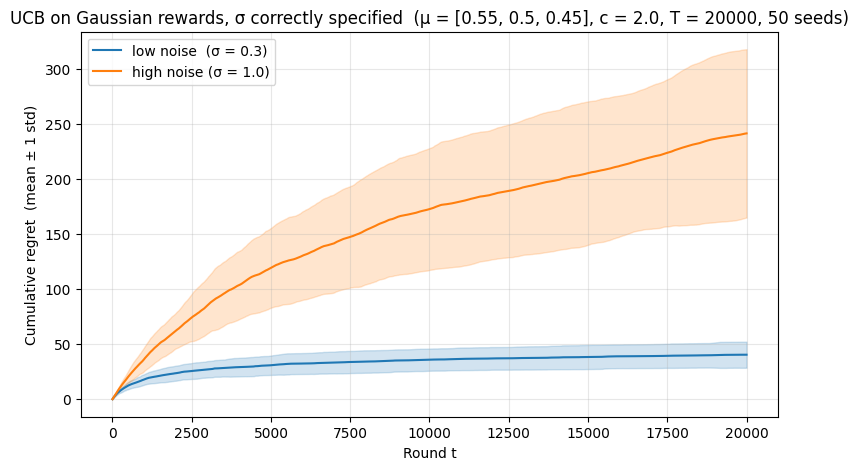

In [21]:
# === Task 1, Part D: UCB on Gaussian rewards, low vs high noise ===

T = 20000
n_seeds = 50
c = 2.0
gaussian_means = [0.55, 0.50, 0.45]

def env_gauss_low(rng):
    return GaussianBandit(gaussian_means, sigma=0.3, rng=rng)

def env_gauss_high(rng):
    return GaussianBandit(gaussian_means, sigma=1.0, rng=rng)

# Tell UCB the correct sigma in each case.
low_regret, _  = run_experiment(partial(ucb, c=c, sigma=0.3), env_gauss_low,  T, n_seeds)
high_regret, _ = run_experiment(partial(ucb, c=c, sigma=1.0), env_gauss_high, T, n_seeds)

fig, ax = plt.subplots(figsize=(9, 5))
plot_averaged_regret(low_regret,  "low noise  (σ = 0.3)",  ax)
plot_averaged_regret(high_regret, "high noise (σ = 1.0)", ax)
ax.set_title(f"UCB on Gaussian rewards, σ correctly specified  (μ = {gaussian_means}, c = {c}, T = {T}, {n_seeds} seeds)")
plt.show()


**Write-up (TODO) — 1 mark.**

Why must the bonus scale with $\sigma$? (Think about how the width of a confidence interval for the mean of $T_i$ Gaussian samples depends on $\sigma$.) And why does the high-noise case produce higher cumulative regret, even though the arm means are identical in the two cases?

*(TODO: write your observations below.)*

**Observations**: Confidence Interval width is defined using multiple of standard deviation only (eg. 95% gaussian confidence interval is mean plus/minus 2 standard deviations). Hence the bonus (width of confidence interval) must scale with $\sigma$ . High noise makes the confidence interval width (and hence UCB) dominated by $\sigma$ only (in spite of lower arm means), so UCB of all arms are high and arms are pulled almost at random in each round, leading to high cumulative regret.

### Part E — when the variance is unknown *(not graded)*

In Part D we told UCB the true $\sigma$. In practice $\sigma$ is unknown — it must be estimated from data or simply guessed. What happens if the guess is wrong? Since the bonus scales linearly with the $\sigma$ we plug in, guessing $\sigma$ too small shrinks every bonus, and guessing too large inflates it.

We fix a Gaussian bandit with true $\sigma = 1.0$ on the hard 3-arm instance, and run UCB with three guessed values: $\sigma = 0.3$ (too small), $\sigma = 1.0$ (correct), $\sigma = 3.0$ (too large).

**Plot 1 — guessing $\sigma$ wrong.** Averaged cumulative regret for the three guesses.

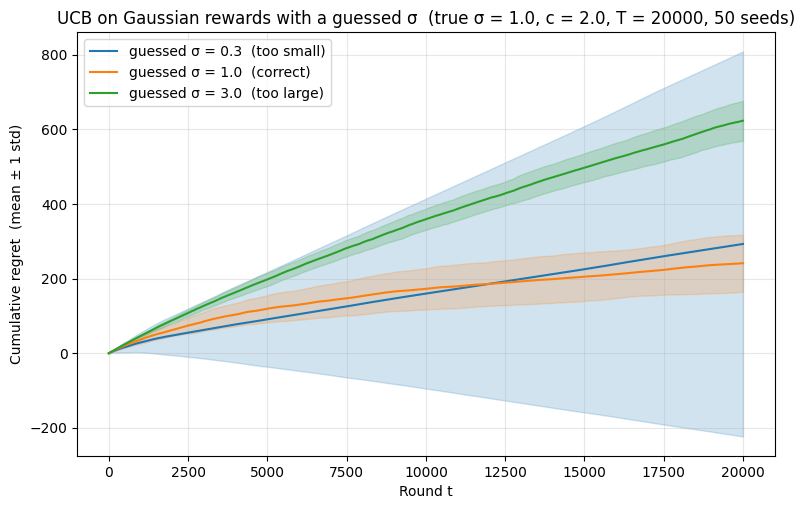

In [22]:
# === Task 1, Part E (not graded): UCB on Gaussian rewards with a guessed sigma ===

T = 20000
n_seeds = 50
c = 2.0
gaussian_means = [0.55, 0.50, 0.45]
true_sigma = 1.0

def env_gauss_true(rng):
    return GaussianBandit(gaussian_means, sigma=true_sigma, rng=rng)

sigma_guesses = [0.3, 1.0, 3.0]            # too small, correct, too large
cumreg_by_sigma = {}

fig, ax = plt.subplots(figsize=(9, 5.5))
for su in sigma_guesses:
    inst_regret, _ = run_experiment(partial(ucb, c=c, sigma=su), env_gauss_true, T, n_seeds)
    cumreg_by_sigma[su] = inst_regret.cumsum(axis=1)
    note = "too small" if su < true_sigma else ("correct" if su == true_sigma else "too large")
    plot_averaged_regret(inst_regret, f"guessed σ = {su}  ({note})", ax)
ax.set_title(f"UCB on Gaussian rewards with a guessed σ  (true σ = {true_sigma}, c = {c}, T = {T}, {n_seeds} seeds)")
plt.show()


**Plot 2 — the spread behind the average.** Final cumulative regret of each seed, one strip per guessed $\sigma$. Look at the too-small guess.

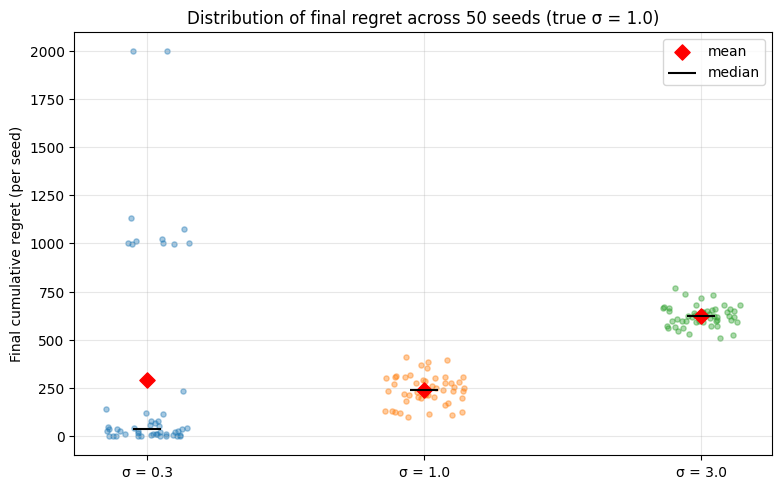

In [23]:
# === Task 1, Part E (not graded): spread across seeds ===

fig, ax = plt.subplots(figsize=(9, 5.5))
positions = np.arange(len(sigma_guesses))
for j, su in enumerate(sigma_guesses):
    pts = cumreg_by_sigma[su][:, -1]
    jitter = (np.random.default_rng(j).random(len(pts)) - 0.5) * 0.3
    ax.scatter(np.full_like(pts, positions[j], dtype=float) + jitter, pts, s=14, alpha=0.4)
    ax.scatter([positions[j]], [pts.mean()], color="red", marker="D", s=60, zorder=5,
               label="mean" if j == 0 else None)
    ax.scatter([positions[j]], [np.median(pts)], color="black", marker="_", s=400, zorder=5,
               label="median" if j == 0 else None)
ax.set_xticks(positions)
ax.set_xticklabels([f"σ = {su}" for su in sigma_guesses])
ax.set_ylabel("Final cumulative regret (per seed)")
ax.set_title(f"Distribution of final regret across {n_seeds} seeds (true σ = {true_sigma})")
ax.legend()
plt.show()


**Write-up (not graded).** Answer if you wish.

1. Relate the three regret curves to the $c$-sweep in Part B. Why does a guessed $\sigma$ that is too small behave like a $c$ that is too small?
2. For the too-small guess, the mean sits far above the median, and the points split into a low group and a high group. What kind of run lands in each group, and why is this a real danger when you do not know $\sigma$ in advance?